In [1]:
import sys
for m in [k for k in sys.modules if k == "RCP_analysis" or k.startswith("RCP_analysis.")]:
    del sys.modules[m]

import RCP_analysis.python.functions.config_loading as cfg
print(cfg.PARAMS.location, cfg.PARAMS.session)
print(cfg.OUT_BASE)

20251203_NRR_RW011 NRR_RW011
/home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results


In [2]:
from pathlib import Path
import numpy as np
import RCP_analysis as rcp

%matplotlib inline

# Config
# rsa params
Z_SCORE_FEATURES = True          # z-score channels across trials before distances
SAVE_SVG = True                  # save under figures/rsa_from_peristim/
MIN_TRIALS_PER_COND = 4          # drop conditions (NPZ files) with fewer trials
MIN_VALID_FEATURES = 2           # trial must have at least this many finite channels
FILE_SLICE = slice(None)         # e.g., slice(None, 10) to cap number of NPZs

# default params
MOVE_BASE_WIN_MS    = (-800.0, -500.0)  # pre-movement baseline window
MOVE_RESP_WIN_MS    = (0.0,  300.0)  # movement response window
STIM_WIN_MS         = (105.0,  150.0)   # window checked for stim-evoked channel responses

# Paths
REPO_ROOT = Path().resolve().parents[2]
PARAMS = rcp.load_experiment_params(
    REPO_ROOT / "config" / "params.yaml",
    repo_root=REPO_ROOT,
)
SESSION_LOC = (Path(PARAMS.data_root) / Path(PARAMS.location)).resolve()
OUT_BASE = SESSION_LOC / "results"
OUT_BASE.mkdir(parents=True, exist_ok=True)

PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"
FIG_DIR = OUT_BASE / "figures" / "rsa_from_peristim"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
cond_label_extras = {
    "Baseline": "Control reaches",
    5: "400Hz (1-32)",
    7: "400Hz (33-64)",
    8: "400Hz (Rest, 4ch)",
    9: "32 ch (Rest, 33-64)",
    10: "130Hz (1-32)",
    11: "130Hz (33-64)",
    12: "1-8",
    13: "5-12",
    14: "9-16",
    15: "13-20",
    16: "17-24",
    17: "21-28",
    18: "25-32",
    19: "29-36",
    20: "33-40",
    21: "37-44",
    23: "32 ch (1-32) Late",
    24: "32 ch (32-64) Late",
    25: "130Hz (1-32) Late",
    27: "130Hz (1-32) Late",
}

In [14]:
SESSION_LOC

PosixPath('/home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011')

In [5]:
import spikeinterface.extractors as se
import spikeinterface.widgets as sw
IR_STREAM = "RHS2000 amplifier channel"
sess = '/home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/Intan/NRR_RW011_251203_142450/'

# rec = se.read_split_intan_files(sess, mode="concatenate", stream_name=IR_STREAM, use_names_as_ids=True)
# sw.plot_traces(rec, channel_ids=['NPXL-117'], time_range=[10.96, 11.08])

In [6]:
file130_1_32 = np.load(
    SESSION_LOC / "results" / "checkpoints" / "PeriStim" / "stim_reaches" / "target_B" / "peristim__NRR_RW011_251203_143709__BR_010_target_B.npz",
    allow_pickle=True,
)
file400_1_32 = np.load(
    SESSION_LOC / "results" / "checkpoints" / "PeriStim" / "stim_reaches" / "target_B" / "peristim__NRR_RW011_251203_141346__BR_005_target_B.npz",
    allow_pickle=True,
)
file130_33_64 = np.load(
    SESSION_LOC / "results" / "checkpoints" / "PeriStim" / "stim_reaches" / "target_B" / "peristim__NRR_RW011_251203_144139__BR_011_target_B.npz",
    allow_pickle=True,
)
# '/Volumes/data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/at_rest/peristim__NRR_RW011_251203_142450__BR_007.npz'
file400_33_64 = np.load(
    SESSION_LOC / "results" / "checkpoints" / "PeriStim" / "stim_reaches" / "target_B" / "peristim__NRR_RW011_251203_142450__BR_007_target_B.npz",
    allow_pickle=True,
)
#10, 5, 11, 7

In [ ]:
file400_1_32['nprw_meta'].item()['stim_channels']

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32],
      dtype=int32)

In [ ]:
file400_33_64['nprw_meta'].item()['stim_channels']

array([33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
       50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64],
      dtype=int32)

In [ ]:
peristim130_1_32 = np.load(
    SESSION_LOC / "results" / "checkpoints" / "PeriStim" / "stim_reaches" / "target_B" / "peristim__NRR_RW011_251203_143709__BR_010_target_B.npz",
    allow_pickle=True)

peristim400_1_32 = np.load(
    SESSION_LOC / "results" / "checkpoints" / "PeriStim" / "stim_reaches" / "target_B" / "peristim__NRR_RW011_251203_141346__BR_005_target_B.npz",
    allow_pickle=True)

peristim130_33_64 = np.load(
    SESSION_LOC / "results" / "checkpoints" / "PeriStim" / "stim_reaches" / "target_B" / "peristim__NRR_RW011_251203_144139__BR_011_target_B.npz",
    allow_pickle=True)

peristim400_33_64 = np.load(
    SESSION_LOC / "results" / "checkpoints" / "PeriStim" / "stim_reaches" / "target_B" / "peristim__NRR_RW011_251203_142450__BR_007_target_B.npz",
    allow_pickle=True)

In [20]:
peristim130_1_32['UA_rates_zeroed']

array([[[-1.29205617e+01, -1.27776630e+01, -1.25322065e+01, ...,
         -1.30953020e+01, -1.30953020e+01, -1.30953020e+01],
        [ 5.06091027e+00,  5.13731561e-01, -3.57198550e+00, ...,
         -1.92990588e+01, -2.26352423e+01, -2.52665945e+01],
        [ 4.66304781e+01,  4.40686570e+01,  3.97547374e+01, ...,
         -3.65064511e+01, -3.30451836e+01, -2.99449256e+01],
        ...,
        [-1.64441552e+01, -1.63012831e+01, -1.60559066e+01, ...,
          2.61128043e+01,  2.51794031e+01,  2.42586271e+01],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          1.12544332e-22,  9.51054433e-24,  7.81595247e-25],
        [-1.65715349e+01, -1.18319969e+01, -6.73209966e+00, ...,
         -3.85977126e+01, -3.98675226e+01, -4.10615772e+01]],

       [[ 5.96079311e+00,  7.35659259e+00,  8.33174676e+00, ...,
         -1.29190157e+01, -1.31643918e+01, -1.33072637e+01],
        [-2.97923490e+01, -2.97134273e+01, -2.90643851e+01, ...,
         -2.88573543e+01, -2.69437449e

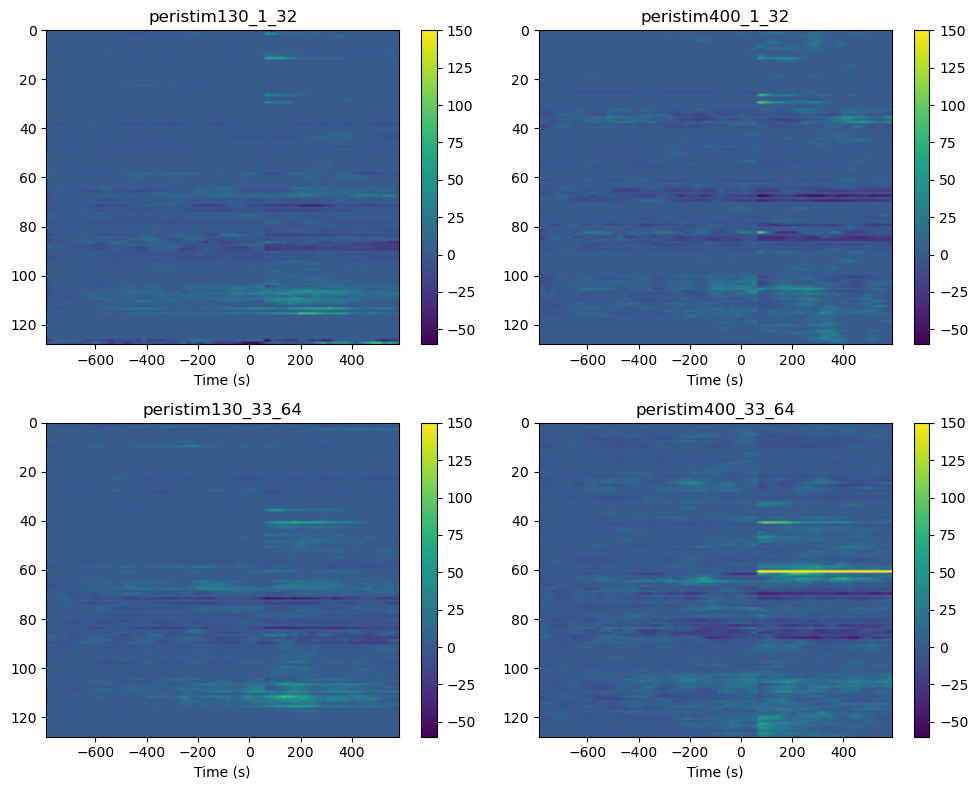

In [21]:
import matplotlib.pyplot as plt

datasets = [
    ("peristim130_1_32", peristim130_1_32),
    ("peristim400_1_32", peristim400_1_32),
    ("peristim130_33_64", peristim130_33_64),
    ("peristim400_33_64", peristim400_33_64),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (name, data) in zip(axes.flat, datasets):
    rates = np.nanmedian(data['NPRW_rates_zeroed'], axis = 0)
    t = data['NPRW_rel_t']
    extent = [t[0], t[-1], rates.shape[0], 0]

    im = ax.imshow(rates, aspect="auto", origin="upper", extent=extent, vmin=-60, vmax=150)
    ax.set_title(name)
    ax.set_xlabel("Time (s)")
    fig.colorbar(im, ax=ax)

fig.tight_layout()
plt.show()

In [ ]:
rcp.run_rsa(
    source="NPRW",
    target="target_B",
    poststim_win_ms=(5.0, 50.0),
    channel_criterion=("movement", "stim", "union", "intersection", None),
    cond_label_extras=cond_label_extras,
    vmin=-0.75, vmax=0.75,
    skip_conds = {2, 3, 6, 8, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27},
    cond_order=["Baseline", 10, 5, 11, 7],
    # move_n_std=1,
    # stim_n_std=2.0,
    debug_masks=True,
)


[run] probe=NPRW  target=target_B  poststim=5.0-50.0ms
[run] baseline: ['BR_002_target_B.npz', 'BR_004_target_B.npz', 'BR_022_target_B.npz']
[run] at_rest: ['BR_008.npz', 'BR_009.npz']
[run][skip] skip_conds=2,3,6,8,12,13,14,15,16,17,18,19,20,21,22,23,24,25,27
[run] baseline (after skip_conds): ['BR_004_target_B.npz']  (dropped: ['BR_002_target_B.npz', 'BR_022_target_B.npz'])
[move] 38/128 channels pass movement criterion
[move][debug-plot] wrote figures/rsa_from_peristim/target_B/debug_NPRW_movement_criterion_baseline-800--500movement0-300.png
[stim] ctrl pool: 11 control trials
[stim] 2/128 pass for BR_005_target_B.npz
[stim] 14/128 pass for BR_007_target_B.npz
[stim] 24/128 pass for BR_010_target_B.npz
[stim] 23/128 pass for BR_011_target_B.npz
[stim] 32/128 pass for BR_009.npz
[stim][union] 59/128 channels passing stim criterion
[stim][debug-plot] saved figures/rsa_from_peristim/target_B/debug_NPRW_stim_criterion_poststim105-150.png


In [44]:
rcp.run_rsa(
    source="UA",
    target="target_B",
    poststim_win_ms=(5.0, 50.0),
    channel_criterion=("movement", "stim", "union", "intersection", None),
    cond_label_extras=cond_label_extras,
    vmin=-0.75, vmax=0.75,
    skip_conds = {2, 3, 6, 8, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27},
    cond_order=["Baseline", 10, 5, 11, 7],
    # move_n_std=1,
    # stim_n_std=2.0,
    debug_masks=True,
)


[run] probe=UA  target=target_B  poststim=5.0-50.0ms
[run] baseline: ['BR_002_target_B.npz', 'BR_004_target_B.npz', 'BR_022_target_B.npz']
[run] at_rest: ['BR_008.npz', 'BR_009.npz']
[run][skip] skip_conds=2,3,6,8,12,13,14,15,16,17,18,19,20,21,22,23,24,25,27
[run] baseline (after skip_conds): ['BR_004_target_B.npz']  (dropped: ['BR_002_target_B.npz', 'BR_022_target_B.npz'])
[move] 7/128 channels pass movement criterion
[move][debug-plot] wrote figures/rsa_from_peristim/target_B/debug_UA_movement_criterion_baseline-800--500movement0-300.png
[stim] ctrl pool: 11 control trials
[stim] 0/128 pass for BR_005_target_B.npz
[stim] 0/128 pass for BR_007_target_B.npz
[stim] 9/128 pass for BR_010_target_B.npz
[stim] 33/128 pass for BR_011_target_B.npz
[stim] 2/128 pass for BR_009.npz
[stim][union] 36/128 channels passing stim criterion
[stim][debug-plot] saved figures/rsa_from_peristim/target_B/debug_UA_stim_criterion_poststim105-150.png
[within] movement: Control reaches=+0.061(n=55)  130Hz (1-